In [81]:
from huggingface_hub import login as hf_login
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import json
from sklearn.model_selection import train_test_split
import sys; sys.path.insert(0, '../datatypes')
from resume_data_type import Resume
from datasets import DatasetDict, Dataset



## Login to hub

In [82]:
# load_dotenv(override=True)
# hf_login()

## Loading the Dataset
Dataset is created using Claude Opus by feeding in the extracted text from resumes to generate a structured JSON.

In [23]:
path_to_dataset = "../datasets/resume_to_json.csv"

In [24]:
df = pd.read_csv(path_to_dataset)
df.head()

,resume_text,structured_json
0,TANVI DAS\ntanvi.das@outlook.com +91 862704726...,"{""contact_info"": {""name"": ""TANVI DAS"", ""email""..."
1,"Ritu Chen\nML Engineer II\nLondon, UK | ritu.c...","{""contact_info"": {""name"": ""Ritu Chen"", ""email""..."
2,TARIQ VERMA\ntherealhacker58@hotmail.com +1 70...,"{""contact_info"": {""name"": ""TARIQ VERMA"", ""emai..."
3,Natasha Smith\nSenior Business Analyst\nAustin...,"{""contact_info"": {""name"": ""Natasha Smith"", ""em..."
4,MANISH PATEL\nmanish.patel@outlook.com +44 784...,"{""contact_info"": {""name"": ""MANISH PATEL"", ""ema..."


In [32]:
sample_idx = 5
contains = "wei zhang"

In [33]:
# print(df['resume_text'].iloc[sample_idx])
print(df[df["resume_text"].str.lower().str.contains(contains)]["resume_text"].iloc[0])

CONTACT
Mumbai, India
wei.zhang@gmail.com
+91 782188696
github.com/weizhang 
linkedin.com/in/wei-zhang
SKILLS
Core / Domain
XGBoost, Python, MLflow, PyTorch,
scikit-learn, pandas, SQL,
Statsmodels
Tools & DevOps
Git, Postman, GitLab CI, Notion,
GitHub
Practices
Pair Programming, System Design,
Agile/Scrum, Code Review, CI/CD
CERTIFICATIONS
 Google Data Analytics Professional
Certificate
 ITIL v4 Foundation
 Microsoft Azure Fundamentals
(AZ-900)
EDUCATION
B.Tech, Computer Science &
Engineering
Delhi Technological University  2018
CGPA 7.3/10
LANGUAGES
English, Tamil
INTERESTS
playing the guitar, open-source
contribution
Wei Zhang
Senior Data Scientist (Kaggle Grandmaster)
PROFESSIONAL SUMMARY
Data scientist who turns ambiguous problems into shipped models. Kaggle
Grandmaster with three gold medals; equally comfortable with rigorous
experimentation and production MLOps. I focus on measurable business
impact, not just leaderboard accuracy.
EXPERIENCE
Senior Data Scientist  HCL
2024  Prese

In [34]:
# sample_json = json.loads(df['structured_json'].iloc[sample_idx])
sample_json = json.loads(df[df["structured_json"].str.lower().str.contains(contains)]["structured_json"].iloc[0])

print(json.dumps(sample_json, indent=4))

{
    "contact_info": {
        "name": "Wei Zhang",
        "email": "wei.zhang@gmail.com",
        "address": "Mumbai, India"
    },
    "description": "Data scientist who turns ambiguous problems into shipped models. Kaggle Grandmaster with three gold medals; equally comfortable with rigorous experimentation and production MLOps. I focus on measurable business impact, not just leaderboard accuracy.",
    "education": [
        {
            "school_name": "Computer Science &",
            "year": "2018",
            "degree": "B.Tech"
        }
    ],
    "skills": [
        "XGBoost",
        "Python",
        "MLflow",
        "PyTorch",
        "scikit-learn",
        "pandas",
        "SQL",
        "Statsmodels",
        "Git",
        "Postman",
        "GitLab CI",
        "Notion",
        "GitHub",
        "Pair Programming",
        "System Design",
        "Agile/Scrum",
        "Code Review",
        "CI/CD"
    ],
    "experience": [
        {
            "company_name"

In [44]:
Resume.model_validate_json(json.dumps(sample_json))

Resume(contact_info=ContactInfo(name='Wei Zhang', email='wei.zhang@gmail.com', address='Mumbai, India'), description='Data scientist who turns ambiguous problems into shipped models. Kaggle Grandmaster with three gold medals; equally comfortable with rigorous experimentation and production MLOps. I focus on measurable business impact, not just leaderboard accuracy.', education=[Education(school_name='Computer Science &', year='2018', degree='B.Tech')], skills=['XGBoost', 'Python', 'MLflow', 'PyTorch', 'scikit-learn', 'pandas', 'SQL', 'Statsmodels', 'Git', 'Postman', 'GitLab CI', 'Notion', 'GitHub', 'Pair Programming', 'System Design', 'Agile/Scrum', 'Code Review', 'CI/CD'], experience=[Experience(company_name='HCL', start_year='2024', end_year='Present', descriptions=['Worked in the Infrastructure team building mobility products.', 'Productionized an ML pipeline with MLflow cutting retraining time by 43%', 'Built a demand-forecasting model with pandas reducing forecast error (MAPE) by 

## Data Analysis

In [47]:
# Checking if all the resume jsons are in correct shape...
resume_jsons = [Resume.model_validate_json(resume_json) for resume_json in df["structured_json"]]
resume_jsons[2]

Resume(contact_info=ContactInfo(name='TARIQ VERMA', email='therealhacker58@hotmail.com', address='London, UK'), description='DATA ANALYST GOOD IN EXCEL AND SQL, WANT TO WORK IN DATA FIELD AND LEARN NEW THINGS.', education=[Education(school_name='Georgia Tech', year='2024', degree='B.E. Information Technology')], skills=['dbt', 'SQL', 'Python (pandas)', 'BigQuery', 'Excel (advanced)'], experience=[], projects=[], certifications=[])

/var/folders/d8/l1z8x_6j4qv99r7plyccwy0h0000gn/T/ipykernel_73649/102096210.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(resume_lengths, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))


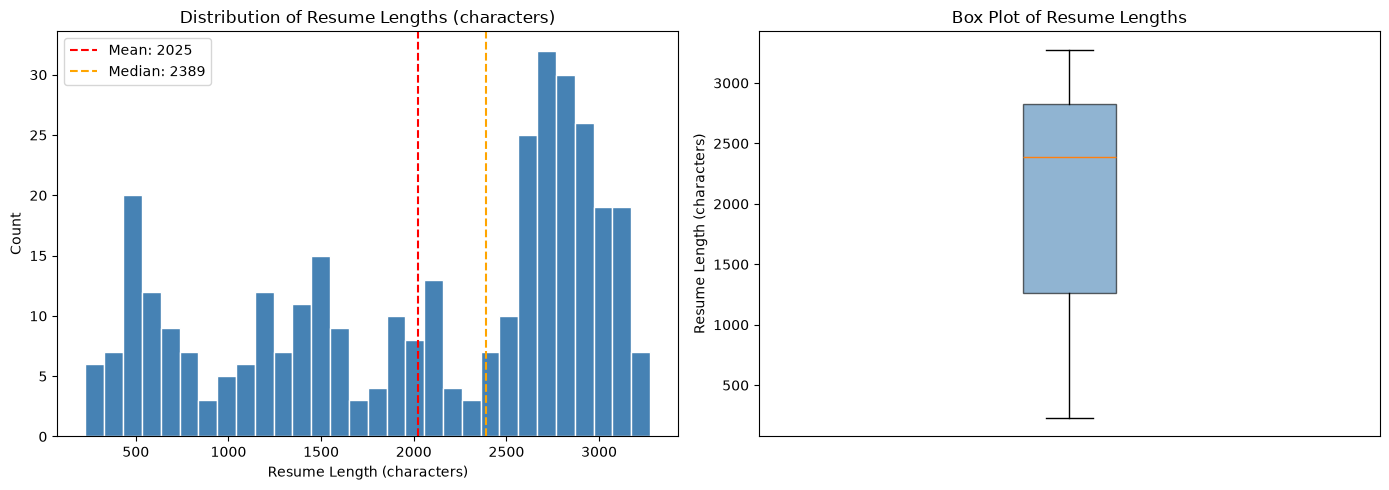

Min:       228
Max:      3275
Mean:     2025
Median:   2389
Std:       918


In [48]:
# Checking the number of characters in each resume texts...
resume_lengths = [len(resume_text) for resume_text in df["resume_text"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(resume_lengths, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(np.mean(resume_lengths), color="red", linestyle="--", label=f"Mean: {np.mean(resume_lengths):.0f}")
axes[0].axvline(np.median(resume_lengths), color="orange", linestyle="--", label=f"Median: {np.median(resume_lengths):.0f}")
axes[0].set_title("Distribution of Resume Lengths (characters)")
axes[0].set_xlabel("Resume Length (characters)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(resume_lengths, vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Box Plot of Resume Lengths")
axes[1].set_ylabel("Resume Length (characters)")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"Min:    {min(resume_lengths):>6}")
print(f"Max:    {max(resume_lengths):>6}")
print(f"Mean:   {np.mean(resume_lengths):>6.0f}")
print(f"Median: {np.median(resume_lengths):>6.0f}")
print(f"Std:    {np.std(resume_lengths):>6.0f}")

In [58]:
# Checking if all the words and sentences from the JSON is extracted from the resume_text and no inference happened...
inferred_texts = []
resume_texts = [text for text in df["resume_text"]]


def _normalize(s: str) -> str:
    """Replace newlines (and any surrounding whitespace) with a single space."""
    return " ".join(s.split())


def _leaf_strings(resume: Resume) -> list[str]:
    """Extract every non-empty string leaf value from a Resume."""
    values = []

    ci = resume.contact_info
    for v in [ci.name, ci.email, ci.address]:
        if v and v.strip():
            values.append(v)

    if resume.description and resume.description.strip():
        values.append(resume.description)

    for edu in resume.education:
        for v in [edu.school_name, edu.year, edu.degree]:
            if v and v.strip():
                values.append(v)

    for skill in resume.skills:
        if skill and skill.strip():
            values.append(skill)

    for exp in resume.experience:
        for v in [exp.company_name, exp.start_year, exp.end_year]:
            if v and v.strip():
                values.append(v)
        for desc in exp.descriptions:
            if desc and desc.strip():
                values.append(desc)

    for proj in resume.projects:
        for v in [proj.name, proj.description]:
            if v and v.strip():
                values.append(v)

    for cert in resume.certifications:
        for v in [cert.name, cert.institute_name, cert.description]:
            if v and v.strip():
                values.append(v)

    return values


for idx, (resume, text) in enumerate(zip(resume_jsons, resume_texts)):
    normalized_text = _normalize(text).lower()
    for value in _leaf_strings(resume):
        if _normalize(value).lower() not in normalized_text:
            inferred_texts.append({"index": idx, "text_from_json": value})

print(f"Total inferred (not found in resume text): {len(inferred_texts)}")
for item in inferred_texts:
    print(item)

Total inferred (not found in resume text): 0


## Saving dataset as hugging face dataset

In [73]:
train_df, temp_df = train_test_split(df, random_state=42, test_size=0.1)
train_df.info()

<class 'pandas.DataFrame'>
Index: 314 entries, 55 to 102
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   resume_text      314 non-null    str  
 1   structured_json  314 non-null    str  
dtypes: str(2)
memory usage: 1.2 MB


In [74]:
valid_df, test_df = train_test_split(temp_df, random_state=42, train_size=0.5)
test_df.info()

<class 'pandas.DataFrame'>
Index: 18 entries, 238 to 124
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   resume_text      18 non-null     str  
 1   structured_json  18 non-null     str  
dtypes: str(2)
memory usage: 63.7 KB


In [78]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(valid_df),
    "test": Dataset.from_pandas(test_df)
}).remove_columns(["__index_level_0__"])
dataset

DatasetDict({
    train: Dataset({
        features: ['resume_text', 'structured_json'],
        num_rows: 314
    })
    validation: Dataset({
        features: ['resume_text', 'structured_json'],
        num_rows: 17
    })
    test: Dataset({
        features: ['resume_text', 'structured_json'],
        num_rows: 18
    })
})

In [ ]:
# Save dataset in huggingface hub
# dataset.push_to_hub("sawarni99/resume-to-json-dataset")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/sawarni99/resume-to-json-dataset/commit/1614fd0a2a22585182ce6a317df5b9edf8d9dfe2', commit_message='Upload dataset', commit_description='', oid='1614fd0a2a22585182ce6a317df5b9edf8d9dfe2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sawarni99/resume-to-json-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sawarni99/resume-to-json-dataset'), pr_revision=None, pr_num=None)